# AIT Log Data Set V2.0 - fox

In [225]:
import pandas as pd
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Concatenate Sensor Files

In [226]:
dataset = "aitv2"
scenario = "santos"
data_dir = f"../data/interim/{dataset}/{scenario}/flows_labeled"
sensor_hosts = ["cloud_share", "inet_firewall", "internal_share", "intranet_server", "mail", "vpn", "webserver", "attacker0"]

In [227]:
df_all_sensors = pd.read_csv(f"{data_dir}/all_flows_labeled_unprocessed.csv")

## Trim to Simulation Period

In [228]:
# Convert start_time and end_time from seconds to datetime
df_all_sensors["start_time_dt"] = pd.to_datetime(df_all_sensors["start_time"], unit="s")
df_all_sensors["end_time_dt"] = pd.to_datetime(df_all_sensors["end_time"], unit="s")

print(f"Full dataset time range: {df_all_sensors['start_time_dt'].min()} to {df_all_sensors['end_time_dt'].max()}")
print("Total flows in combined dataset:", len(df_all_sensors))

Full dataset time range: 2022-01-13 13:20:45.726470947 to 2022-01-18 05:41:41.618597031
Total flows in combined dataset: 599243


In [229]:
# Trim to simulation period
sim_start = pd.Timestamp("2022-01-14 00:00")
sim_end   = pd.Timestamp("2022-01-18 00:00")

df_sim = df_all_sensors[(df_all_sensors["start_time_dt"] >= sim_start) & (df_all_sensors["end_time_dt"] <= sim_end)]

print(f"Simulation period: {sim_start} to {sim_end}")
print(f"Total flows in simulation period: {len(df_sim)}")

Simulation period: 2022-01-14 00:00:00 to 2022-01-18 00:00:00
Total flows in simulation period: 559329


## Sanity Check Labeling

### Load Netflow Data

In [230]:
netflows_path = f"../data/raw/{dataset}/{scenario}/netflows/all_netflows.csv"

df_netflows = pd.read_csv(netflows_path)
df_netflows_labels_counts = df_netflows["label"].value_counts()
netflows_labels = df_netflows["label"].unique()

print(netflows_labels)
print(df_netflows_labels_counts)
print()

['browsing/update' 'service_scan' 'online_cracking' 'benign_share' 'proxy'
 'host_discover_dmz' 'SSH' 'mail' 'DNS'
 'update/command on unassigned port' 'monitoring' 'HTTP' 'HTTP(S) intra'
 'HTTPS' 'host_discover_local' 'dirb_scan' 'wpscan' 'upload_rce_shell'
 'list_www' 'check_user_id' 'check_id' 'check_netstat_nat' 'check_whoami'
 'check_date' 'check_meminfo' 'check_netstat_l' 'check_who' 'check_pwd'
 'clear' 'check_network_config' 'list_l' 'check_uname_r' 'check_ps_a'
 'read_resolv' 'check_last' 'check_uptime' 'read_passwd' 'check_release'
 'check_netstat_t' 'check_df' 'list_web_dir' 'check_uname_a' 'list_home'
 'read_group' 'check_wp_config' 'dump_wp_users' 'dns_brute_force_start'
 'HTTP(S) DMZ' 'broken flow - benign' 'data exfiltration' 'NTP' 'mDNSv6'
 'mDNS' 'bootp' 'systemd-resolver (local)'
 'benign DNS - attacker requesting updates' 'benign DNS' 'QUIC' 'OpenVPN'
 'STUN VoIP' 'NetBIOS']
label
proxy              84132
benign DNS         70915
HTTP(S) DMZ        38200
browsing/upd

### Check Labeling

In [231]:
def get_observed_labels_and_counts(df):
    observed_labels = set()
    observed_labels_counts = {}
    for label in df["label"].unique():
        observed_labels.add(label)
        observed_labels_counts[label] = len(df[df["label"] == label])
    return observed_labels, observed_labels_counts

observed_labels, observed_labels_counts = get_observed_labels_and_counts(df_sim)

In [232]:
print("Unique labels observed across all sensors:")
print(list(observed_labels))

print("Labels in netflows but not observed:")
missing_labels = [label for label in netflows_labels if label not in observed_labels]
print(missing_labels)

Unique labels observed across all sensors:
['NTP', 'benign', 'read_passwd', 'benign DNS - attacker requesting updates', 'HTTPS', 'data exfiltration', 'read_resolv', 'benign_share', 'broken flow - benign', 'monitoring', 'check_who', 'clear', 'check_netstat_l', 'read_group', 'check_uname_r', 'check_ps_a', 'host_discover_local', 'check_pwd', 'bootp', 'HTTP', 'check_meminfo', 'proxy', 'SSH', 'QUIC', 'upload_rce_shell', 'OpenVPN', 'check_df', 'check_id', 'browsing/update', 'check_last', 'DNS', 'mail', 'dump_wp_users', 'HTTP(S) intra', 'update/command on unassigned port', 'dns_brute_force_start', 'online_cracking', 'check_wp_config', 'list_l', 'STUN VoIP', 'check_release', 'check_user_id', 'check_uptime', 'check_netstat_t', 'list_web_dir', 'check_uname_a', 'wpscan', 'check_whoami', 'check_network_config', 'list_home', 'list_www', 'HTTP(S) DMZ', 'dirb_scan', 'service_scan', 'check_netstat_nat', 'check_date', 'systemd-resolver (local)', 'host_discover_dmz', 'benign DNS']
Labels in netflows but

In [233]:
for label in observed_labels:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'NTP': 7327
Number of flows with label 'NTP' in netflows: 7122

Observed number of flows with label 'benign': 134136
Number of flows with label 'benign' in netflows: 0

Observed number of flows with label 'read_passwd': 4
Number of flows with label 'read_passwd' in netflows: 2

Observed number of flows with label 'benign DNS - attacker requesting updates': 173
Number of flows with label 'benign DNS - attacker requesting updates' in netflows: 51

Observed number of flows with label 'HTTPS': 31738
Number of flows with label 'HTTPS' in netflows: 15877

Observed number of flows with label 'data exfiltration': 38548
Number of flows with label 'data exfiltration' in netflows: 12848

Observed number of flows with label 'read_resolv': 4
Number of flows with label 'read_resolv' in netflows: 2

Observed number of flows with label 'benign_share': 7893
Number of flows with label 'benign_share' in netflows: 3940

Observed number of flows with label 'broken flow -

In [234]:
label = "data exfiltration"
print("Data exfiltration label counts:")
print(f"Observed: {observed_labels_counts.get(label, 0)}")
print(f"Netflows: {df_netflows_labels_counts.get(label, 0)}")

Data exfiltration label counts:
Observed: 38548
Netflows: 12848


### Remove Duplicates

In [235]:
# def compute_hash(df: pd.DataFrame, columns: list) -> pd.Series:
#     return (
#         df[columns]
#         .astype(str)
#         .agg("|".join, axis=1)
#         .apply(lambda x: hashlib.md5(x.encode()).hexdigest())
#     )

In [236]:
# df_sim["start_time_match"] = df_sim["start_time"].round(1)
# df_sim["end_time_match"] = df_sim["end_time"].round(1)

# match_columns = [col for col in df_sim.columns if col not in ["flow_id", "start_time", "end_time", "sensor_host"]]
# match_columns.append("start_time_match")
# match_columns.append("end_time_match")
# print("Matching columns:", match_columns)

# # Compute flow hash for all sensor flows
# df_sim["flow_hash"] = compute_hash(df_sim, match_columns)

In [238]:
# Remove duplicates by keeping only one entry per flow hash and sensor host
df_sim_no_duplicates = (
    df_sim
    .drop_duplicates(subset=["flow_hash", "sensor_host"])
    .drop(columns=["flow_hash", "start_hash", "end_hash"])
)

print("Original dataset shape:", df_sim.shape)
print("Final dataset shape:", df_sim_no_duplicates.shape)

Original dataset shape: (559329, 30)
Final dataset shape: (352749, 27)


In [239]:
observed_labels_no_duplicates, observed_labels_counts_no_duplicates = \
    get_observed_labels_and_counts(df_sim_no_duplicates)

for label in observed_labels_no_duplicates:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts_no_duplicates[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'NTP': 7033
Number of flows with label 'NTP' in netflows: 7122

Observed number of flows with label 'benign': 67322
Number of flows with label 'benign' in netflows: 0

Observed number of flows with label 'read_passwd': 2
Number of flows with label 'read_passwd' in netflows: 2

Observed number of flows with label 'benign DNS - attacker requesting updates': 49
Number of flows with label 'benign DNS - attacker requesting updates' in netflows: 51

Observed number of flows with label 'HTTPS': 15884
Number of flows with label 'HTTPS' in netflows: 15877

Observed number of flows with label 'data exfiltration': 12861
Number of flows with label 'data exfiltration' in netflows: 12848

Observed number of flows with label 'read_resolv': 2
Number of flows with label 'read_resolv' in netflows: 2

Observed number of flows with label 'benign_share': 3942
Number of flows with label 'benign_share' in netflows: 3940

Observed number of flows with label 'broken flow - b

### Save Final Dataset

In [241]:
df_sim_no_duplicates.to_csv(f"{data_dir}/all_flows_labeled_sim.csv", index=False)
print("Combined dataset shape:", df_sim_no_duplicates.shape)
df_sim_no_duplicates.head()

Combined dataset shape: (352749, 27)


,flow_id,start_time,end_time,duration,src_ip,sport,dst_ip,dport,proto,service,...,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,sensor_host,start_time_dt,end_time_dt
36778,f1115,1.642118e+09,1.642118e+09,0.021806,172.21.128.54,55156,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-14 00:00:02.425734043,2022-01-14 00:00:02.447540045
36780,f3100,1.642118e+09,1.642118e+09,0.019958,172.21.128.54,55156,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-14 00:00:02.427603960,2022-01-14 00:00:02.447561979
36782,f1116,1.642118e+09,1.642118e+09,0.011838,172.21.128.54,55158,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-14 00:00:02.512283087,2022-01-14 00:00:02.524121046
36784,f3101,1.642118e+09,1.642118e+09,0.010949,172.21.128.54,55158,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-14 00:00:02.513200997,2022-01-14 00:00:02.524149895
36786,f3102,1.642118e+09,1.642118e+09,0.005656,192.168.104.218,35467,192.168.104.1,53,udp,dns,...,1,296,1,312,-,17,benign DNS,internal_share,2022-01-14 00:00:09.728241920,2022-01-14 00:00:09.733897924


## Plotting

In [242]:
df = df_sim_no_duplicates.copy()

### Plotting Functions

In [243]:
def plot_event_raster(df_attack, order, attack=False, invert_y=True):

    plt.figure(figsize=(14, 0.35 * len(order)))

    sample = df_attack.sample(
        min(len(df_attack), 5000),
        random_state=0
    ).sort_values("start_time_dt")

    label_to_idx = {lbl: i for i, lbl in enumerate(order)}

    ys = sample['label'].map(label_to_idx).astype(float)

    # jitter to reveal density
    ys += np.random.uniform(-0.15, 0.15, size=len(ys))

    # horizontal guides
    for y in label_to_idx.values():
        plt.axhline(y, color="lightgray", lw=0.5, zorder=0)

    plt.scatter(
        sample['start_time_dt'],  
        ys,
        s=2,
        alpha=0.5,
        rasterized=True
    )

    plt.yticks(list(label_to_idx.values()), list(label_to_idx.keys()))

    plt.grid(axis="x", linestyle=":", alpha=0.4)

    plt.xlabel("Time")
    plt.ylabel("Event Type")
    plt.title("Attack Event Timeline (Sampled Raster)", pad=12)

    ax = plt.gca()

    if attack:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.xticks(rotation=30)

    if invert_y:
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

### Analyze All Events

In [244]:
all_labels = list(netflows_labels)
all_labels.append("benign")
print("All labels (netflows + benign):", all_labels)

All labels (netflows + benign): ['browsing/update', 'service_scan', 'online_cracking', 'benign_share', 'proxy', 'host_discover_dmz', 'SSH', 'mail', 'DNS', 'update/command on unassigned port', 'monitoring', 'HTTP', 'HTTP(S) intra', 'HTTPS', 'host_discover_local', 'dirb_scan', 'wpscan', 'upload_rce_shell', 'list_www', 'check_user_id', 'check_id', 'check_netstat_nat', 'check_whoami', 'check_date', 'check_meminfo', 'check_netstat_l', 'check_who', 'check_pwd', 'clear', 'check_network_config', 'list_l', 'check_uname_r', 'check_ps_a', 'read_resolv', 'check_last', 'check_uptime', 'read_passwd', 'check_release', 'check_netstat_t', 'check_df', 'list_web_dir', 'check_uname_a', 'list_home', 'read_group', 'check_wp_config', 'dump_wp_users', 'dns_brute_force_start', 'HTTP(S) DMZ', 'broken flow - benign', 'data exfiltration', 'NTP', 'mDNSv6', 'mDNS', 'bootp', 'systemd-resolver (local)', 'benign DNS - attacker requesting updates', 'benign DNS', 'QUIC', 'OpenVPN', 'STUN VoIP', 'NetBIOS', 'benign']


In [245]:
phase_bounds_sim = (
    df[df['label'].isin(all_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_sim

,min,max
label,,
benign_share,2022-01-14 00:00:02.425734043,2022-01-17 23:45:02.306144953
benign DNS,2022-01-14 00:00:09.728241920,2022-01-17 23:58:37.136760950
data exfiltration,2022-01-14 00:00:09.731323957,2022-01-16 07:16:04.975357056
benign,2022-01-14 00:00:23.517299890,2022-01-17 23:59:07.776370049
browsing/update,2022-01-14 00:00:23.922441006,2022-01-17 23:44:37.067908049
NTP,2022-01-14 00:00:58.747752905,2022-01-17 23:59:53.819441080
monitoring,2022-01-14 00:09:05.722054005,2022-01-17 23:39:05.678922892
broken flow - benign,2022-01-14 04:22:55.214932919,2022-01-17 23:09:07.756174088
systemd-resolver (local),2022-01-14 05:14:57.174271107,2022-01-17 11:58:57.583493948


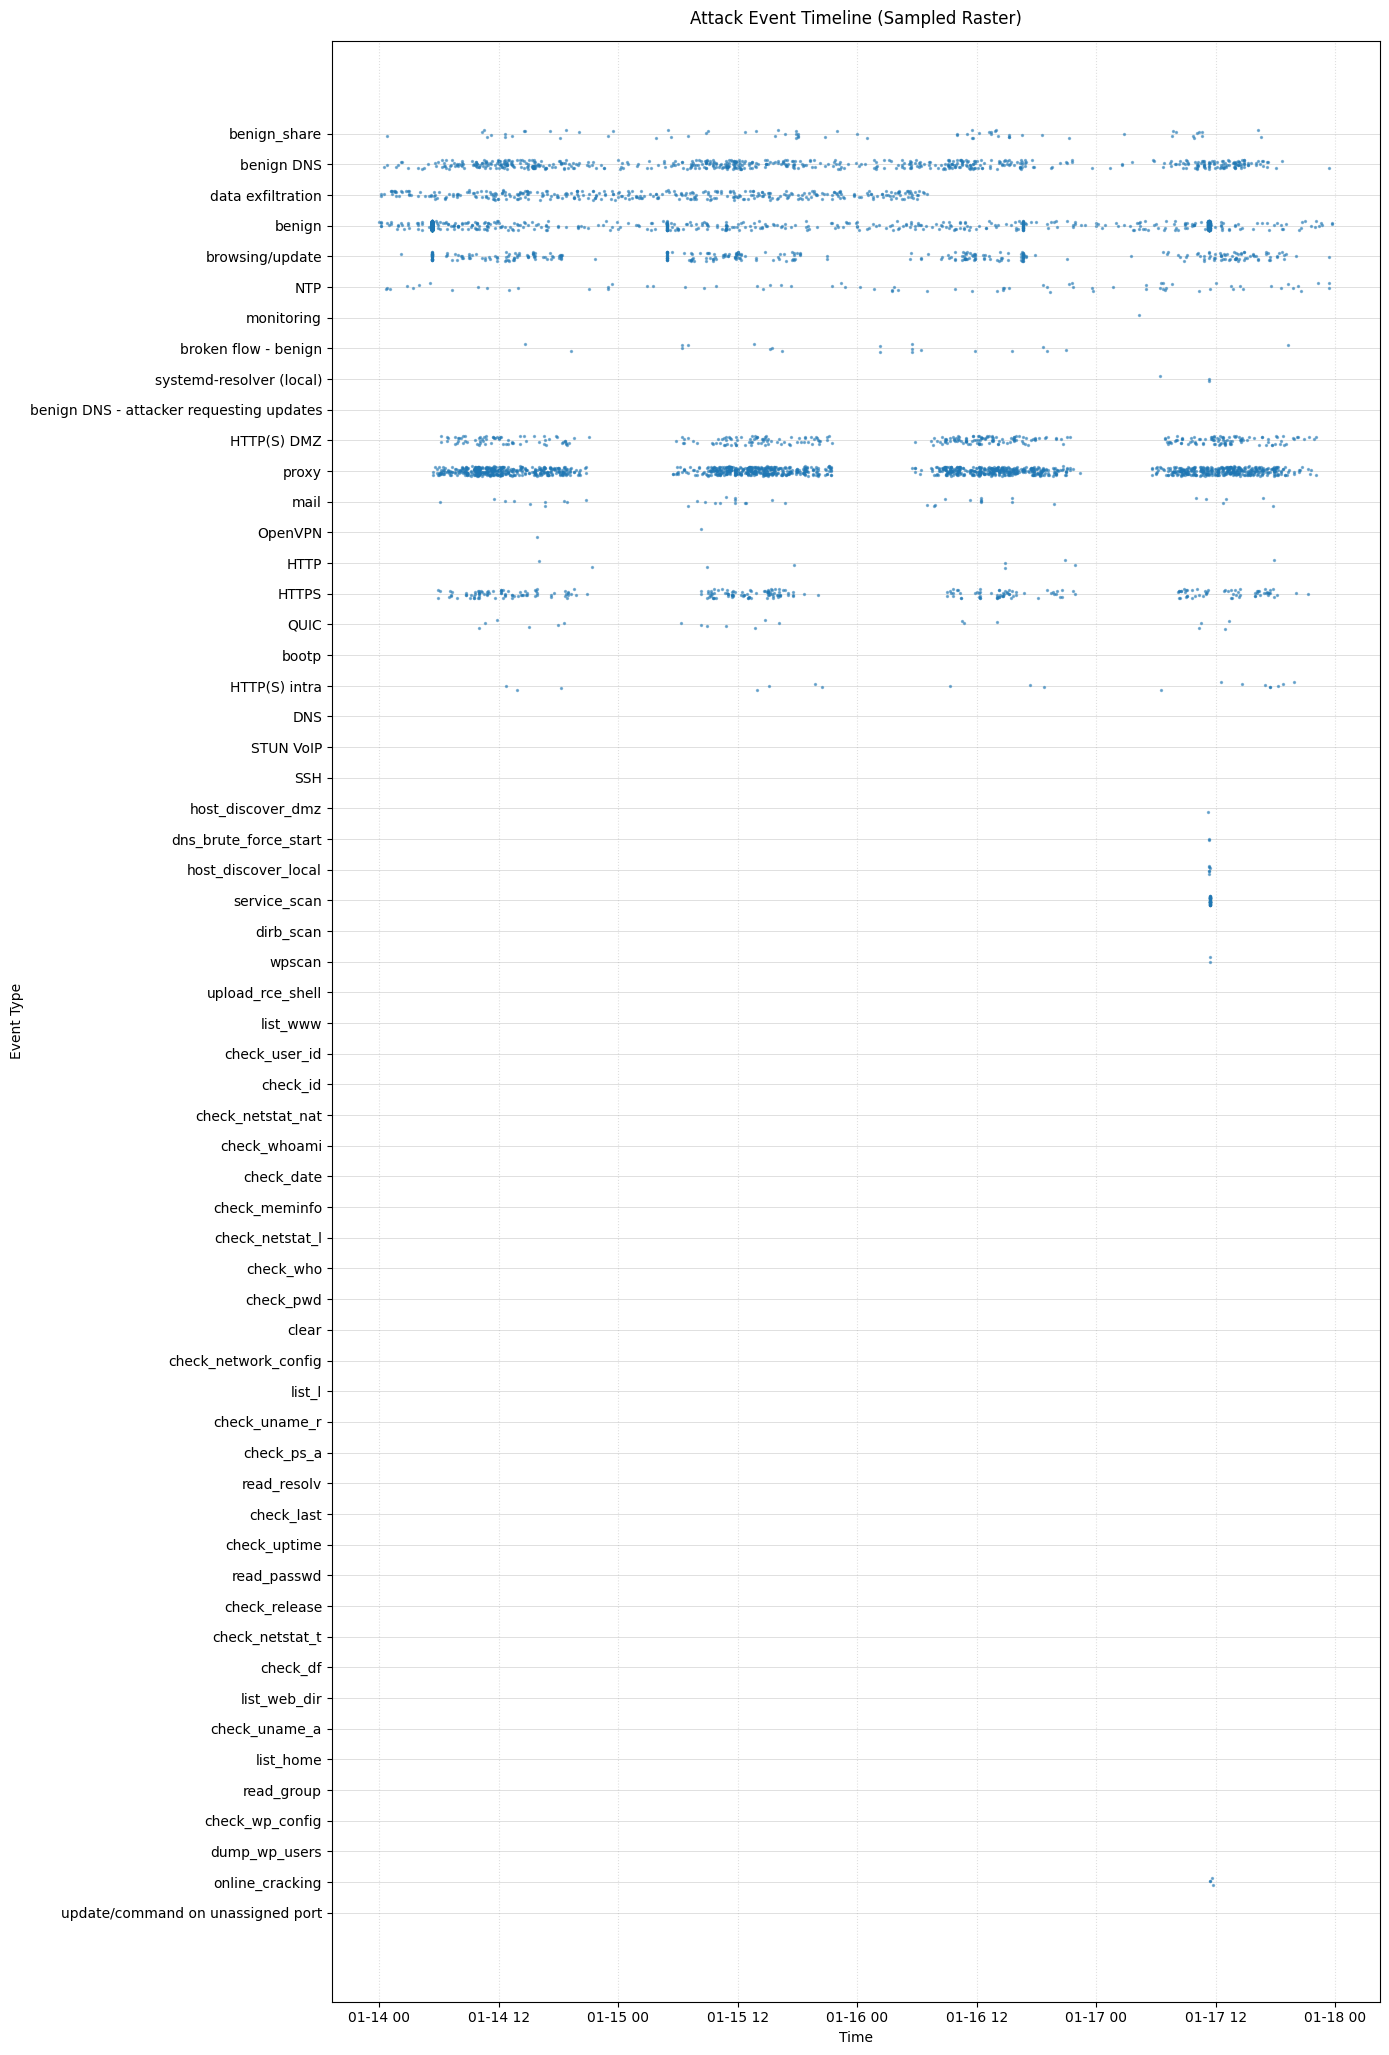

In [246]:
order_sim = phase_bounds_sim.index.tolist()
plot_event_raster(df_sim, order_sim)

### Only Attacks

In [247]:
benign_labels = ["DNS", "SSH", "HTTP(S) DMZ", "mail", "proxy", "HTTPS", "HTTP", "HTTP(S) intra", "browsing/update", "monitoring", "benign_share", "benign", "benign DNS", "NTP", "broken flow - benign", "bootp", "OpenVPN", "QUIC", "STUN VoIP"]
attack_labels = [lbl for lbl in all_labels if lbl not in benign_labels]
print("Benign labels:", benign_labels)
print("Attack labels:", attack_labels)

Benign labels: ['DNS', 'SSH', 'HTTP(S) DMZ', 'mail', 'proxy', 'HTTPS', 'HTTP', 'HTTP(S) intra', 'browsing/update', 'monitoring', 'benign_share', 'benign', 'benign DNS', 'NTP', 'broken flow - benign', 'bootp', 'OpenVPN', 'QUIC', 'STUN VoIP']
Attack labels: ['service_scan', 'online_cracking', 'host_discover_dmz', 'update/command on unassigned port', 'host_discover_local', 'dirb_scan', 'wpscan', 'upload_rce_shell', 'list_www', 'check_user_id', 'check_id', 'check_netstat_nat', 'check_whoami', 'check_date', 'check_meminfo', 'check_netstat_l', 'check_who', 'check_pwd', 'clear', 'check_network_config', 'list_l', 'check_uname_r', 'check_ps_a', 'read_resolv', 'check_last', 'check_uptime', 'read_passwd', 'check_release', 'check_netstat_t', 'check_df', 'list_web_dir', 'check_uname_a', 'list_home', 'read_group', 'check_wp_config', 'dump_wp_users', 'dns_brute_force_start', 'data exfiltration', 'mDNSv6', 'mDNS', 'systemd-resolver (local)', 'benign DNS - attacker requesting updates', 'NetBIOS']


In [248]:
attack_start_true = pd.Timestamp("2022-01-17 11:15")
attack_end_true   = pd.Timestamp("2022-01-17 11:59")

print(f"True attack period:")
print(f"{attack_start_true} to {attack_end_true}")
print()

df_attack = df[df["label"].isin(attack_labels)]
attack_start = df_attack["start_time_dt"].min()
attack_end = df_attack["end_time_dt"].max()

print(f"Attack period based on attack labels:")
print(f"{attack_start} to {attack_end}")
print()

print(f"Total attack flows in attack period: {len(df_attack)}")

True attack period:
2022-01-17 11:15:00 to 2022-01-17 11:59:00

Attack period based on attack labels:
2022-01-14 00:00:09.731323957 to 2022-01-17 11:58:57.603799105

Total attack flows in attack period: 19225


In [249]:
phase_bounds_attack = (
    df_attack[df_attack['label'].isin(attack_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_attack

,min,max
label,,
data exfiltration,2022-01-14 00:00:09.731323957,2022-01-16 07:16:04.975357056
systemd-resolver (local),2022-01-14 05:14:57.174271107,2022-01-17 11:58:57.583493948
benign DNS - attacker requesting updates,2022-01-14 05:14:57.175551891,2022-01-17 07:44:25.606261015
host_discover_dmz,2022-01-17 11:15:12.900707960,2022-01-17 11:20:35.309524059
dns_brute_force_start,2022-01-17 11:21:09.514715910,2022-01-17 11:21:10.257448911
host_discover_local,2022-01-17 11:21:21.226320028,2022-01-17 11:21:23.334497929
service_scan,2022-01-17 11:21:32.394479990,2022-01-17 11:21:46.958153009
dirb_scan,2022-01-17 11:22:02.550590038,2022-01-17 11:22:13.053563118
wpscan,2022-01-17 11:22:23.349515915,2022-01-17 11:22:44.917221069


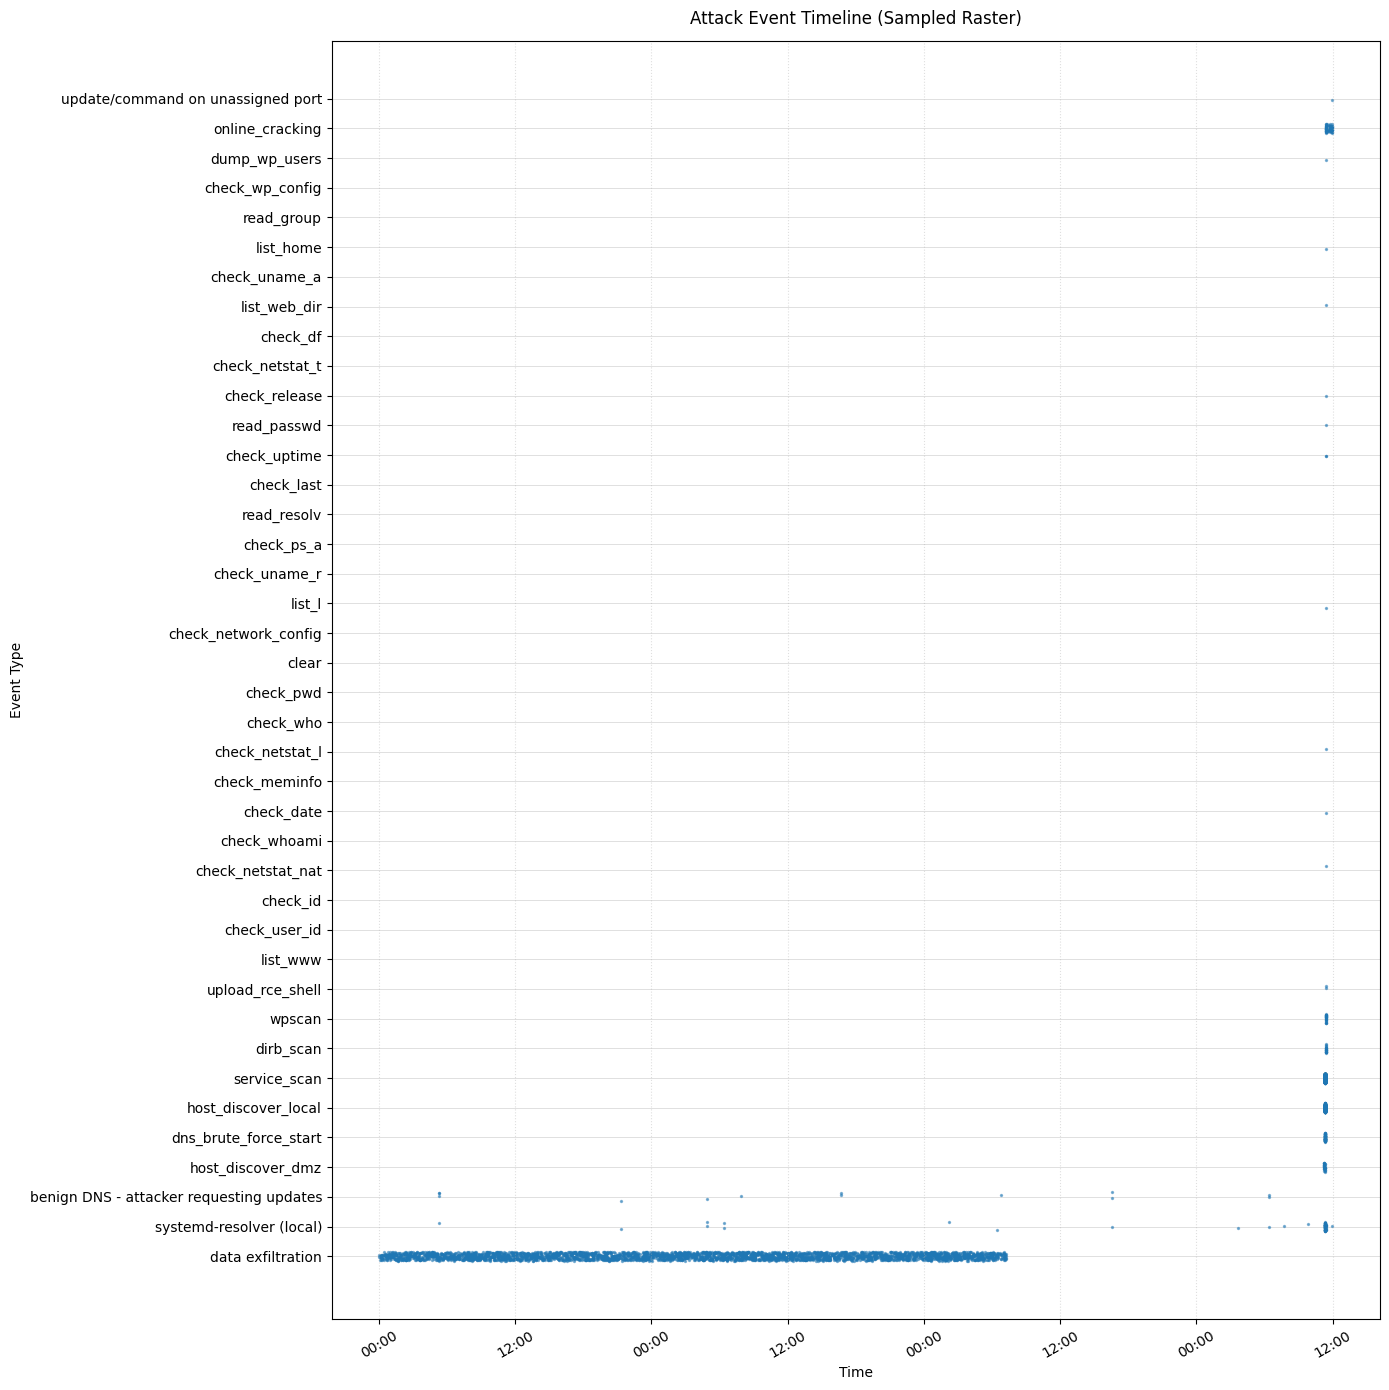

In [250]:
order_attack = phase_bounds_attack.index.tolist()
plot_event_raster(df_attack=df_attack, order=order_attack, attack=True, invert_y=False)

## Dataset Statistics

In [251]:
def label_stats(df, sensor_host, plot_bar=True):
    label_counts = df["label"].value_counts()
    print("Label Distribution for {}:".format(sensor_host))
    print(label_counts)

    if plot_bar:
        bar = label_counts.plot(kind="bar")
        bar.set_title("Label Distribution - {}".format(sensor_host))
        bar.set_yscale("log")
    print()

In [252]:
def dataset_stats(df, print_details=True):
    total_flows = len(df)
    unique_src_ips = df["src_ip"].nunique()
    unique_dst_ips = df["dst_ip"].nunique()
    unique_src_ports = df["sport"].nunique()
    unique_dst_ports = df["dport"].nunique()

    if print_details:
        print(f"Total Flows: {total_flows}")
        print(f"Unique Source IPs: {unique_src_ips}")
        print(f"Unique Destination IPs: {unique_dst_ips}")
        print(f"Unique Source Ports: {unique_src_ports}")
        print(f"Unique Destination Ports: {unique_dst_ports}")

    return {
        "total_flows": total_flows,
        "unique_src_ips": unique_src_ips,
        "unique_dst_ips": unique_dst_ips,
        "unique_src_ports": unique_src_ports,
        "unique_dst_ports": unique_dst_ports,
    }

In [253]:
def dataset_stats_detailed(df, print_details=True):
    src_ips = df["src_ip"].value_counts()
    dst_ips = df["dst_ip"].value_counts()
    src_ports = df["sport"].value_counts()
    dst_ports = df["dport"].value_counts()

    if print_details:
        print("Total Flows:", len(df))

        print("\n --- IP distribution ---")
        print(f"\nSource IPs ({len(src_ips)}):")
        print(src_ips)
        print(f"\nDestination IPs ({len(dst_ips)}):")
        print(dst_ips)

        print("\n --- Port distribution ---")
        print(f"Source Ports ({len(src_ports)}):")
        print(src_ports)
        print(f"\nDestination Ports ({len(dst_ports)}):")
        print(dst_ports)

    return src_ips, dst_ips, src_ports, dst_ports

Label Distribution for All Sensors:
label
data exfiltration                           12861
service_scan                                 4056
host_discover_local                          1000
systemd-resolver (local)                      356
dns_brute_force_start                         325
online_cracking                               228
host_discover_dmz                             115
dirb_scan                                      90
wpscan                                         84
benign DNS - attacker requesting updates       49
update/command on unassigned port               3
upload_rce_shell                                2
check_id                                        2
check_netstat_nat                               2
list_www                                        2
check_user_id                                   2
check_meminfo                                   2
check_netstat_l                                 2
check_who                                       2
check_pw

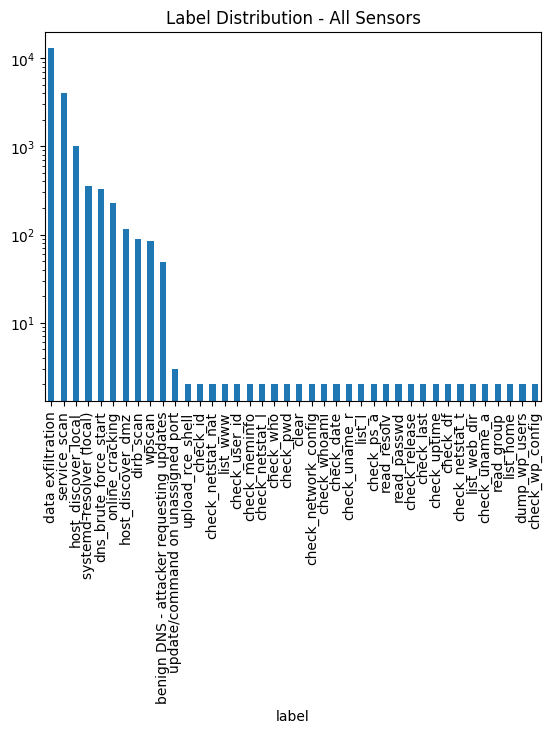

In [254]:
label_stats(df_attack, "All Sensors")

In [255]:
# Sim dataset stats
dataset_stats(df)

Total Flows: 352749
Unique Source IPs: 130
Unique Destination IPs: 12029
Unique Source Ports: 47841
Unique Destination Ports: 1084


{'total_flows': 352749,
 'unique_src_ips': 130,
 'unique_dst_ips': 12029,
 'unique_src_ports': 47841,
 'unique_dst_ports': 1084}

In [256]:
# Attack flows stats
dataset_stats(df_attack)

Total Flows: 19225
Unique Source IPs: 7
Unique Destination IPs: 266
Unique Source Ports: 15112
Unique Destination Ports: 593


{'total_flows': 19225,
 'unique_src_ips': 7,
 'unique_dst_ips': 266,
 'unique_src_ports': 15112,
 'unique_dst_ports': 593}

In [257]:
dataset_stats_detailed(df_attack)

Total Flows: 19225

 --- IP distribution ---

Source IPs (7):
src_ip
10.229.255.254     12861
172.21.128.119      5354
10.229.2.216         645
127.0.0.1            356
10.229.0.4             5
192.168.104.155        2
10.229.1.118           2
Name: count, dtype: int64

Destination IPs (266):
dst_ip
10.229.2.216       12867
192.168.104.155     1133
172.21.131.50        896
172.21.128.54        870
192.168.104.218      841
                   ...  
192.168.104.95         1
192.168.104.198        1
192.168.104.141        1
192.168.104.81         1
192.168.104.98         1
Name: count, Length: 266, dtype: int64

 --- Port distribution ---
Source Ports (15112):
sport
35788    6
48932    6
48916    6
46186    6
35656    6
        ..
37299    1
26759    1
42331    1
59055    1
63303    1
Name: count, Length: 15112, dtype: int64

Destination Ports (593):
dport
53       13277
443       1100
80         608
587         26
139         14
         ...  
8873         5
5633         5
800          5


(src_ip
 10.229.255.254     12861
 172.21.128.119      5354
 10.229.2.216         645
 127.0.0.1            356
 10.229.0.4             5
 192.168.104.155        2
 10.229.1.118           2
 Name: count, dtype: int64,
 dst_ip
 10.229.2.216       12867
 192.168.104.155     1133
 172.21.131.50        896
 172.21.128.54        870
 192.168.104.218      841
                    ...  
 192.168.104.95         1
 192.168.104.198        1
 192.168.104.141        1
 192.168.104.81         1
 192.168.104.98         1
 Name: count, Length: 266, dtype: int64,
 sport
 35788    6
 48932    6
 48916    6
 46186    6
 35656    6
         ..
 37299    1
 26759    1
 42331    1
 59055    1
 63303    1
 Name: count, Length: 15112, dtype: int64,
 dport
 53       13277
 443       1100
 80         608
 587         26
 139         14
          ...  
 8873         5
 5633         5
 800          5
 1088         5
 16486        3
 Name: count, Length: 593, dtype: int64)

## Multi-Step Attack Labels

In [258]:
recon = ['dns_brute_force_start', 'host_discover_local', 'host_discover_dmz', 'service_scan', 'wpscan', 'dirb_scan']
exploit = ['upload_rce_shell', 'check_user_id', 'check_netstat_t', 'read_resolv', 'check_network_config', 'check_ps_a', 'check_release', 'read_group', 'read_passwd', 'check_date', 'list_web_dir', 'check_wp_config', 'dump_wp_users', 'read_profile']
cracking = ['online_cracking']
escalation = ['update/command on unassigned port']

In [259]:
df_sim = pd.read_csv(f"{data_dir}/all_flows_labeled_sim.csv")

In [260]:
def label_phase(label):
    if label in recon:
        return 1
    elif label in exploit:
        return 2
    elif label in cracking:
        return 3
    elif label in escalation:
        return 4
    else:
        return 0

df_sim["phase"] = df_sim["label"].apply(label_phase)
label_counts = df_sim["phase"].value_counts()
print("Phase distribution:")
print(label_counts)

Phase distribution:
phase
0    346822
1      5670
3       228
2        26
4         3
Name: count, dtype: int64


In [261]:
df_sim.to_csv(f"{data_dir}/all_flows_labeled.csv", index=False)

## Try and find data exfil flows 

In [262]:
src_ip = "10.229.255.254"
dst_ip = "10.229.2.216"
dport = 53
start_time = 1642118409
end_time = 1642246587

In [263]:
exfil_flows = df_sim[
    (df_sim["src_ip"] == dst_ip) &
    (df_sim["dst_ip"] == src_ip) 
    # (df_sim["dport"] == dport) &
    # (round(df_sim["start_time"]).astype(int) >= start_time) &
    # (round(df_sim["end_time"]).astype(int) <= end_time)
]

In [264]:
exfil_flows

,flow_id,start_time,end_time,duration,src_ip,sport,dst_ip,dport,proto,service,...,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,sensor_host,start_time_dt,end_time_dt,phase
6083,f4669,1.642137e+09,1.642137e+09,0.013845,10.229.2.216,39294,10.229.255.254,53,udp,dns,...,163,2,285,-,17,benign DNS - attacker requesting updates,attacker0,2022-01-14 05:14:57.175551891,2022-01-14 05:14:57.189396858,0
6084,f29107,1.642137e+09,1.642137e+09,0.000000,10.229.2.216,53009,10.229.255.254,53,udp,dns,...,86,0,0,-,17,benign DNS - attacker requesting updates,attacker0,2022-01-14 05:14:57.175712109,2022-01-14 05:14:57.175712109,0
6086,f4672,1.642137e+09,1.642137e+09,0.005861,10.229.2.216,34706,10.229.255.254,53,udp,dns,...,75,1,107,-,17,benign DNS - attacker requesting updates,attacker0,2022-01-14 05:14:57.184487104,2022-01-14 05:14:57.190347910,0
6087,f4673,1.642137e+09,1.642137e+09,0.019758,10.229.2.216,59649,10.229.255.254,53,udp,dns,...,75,1,131,-,17,benign DNS - attacker requesting updates,attacker0,2022-01-14 05:14:57.184664965,2022-01-14 05:14:57.204422951,0
6089,f29121,1.642137e+09,1.642137e+09,0.000000,10.229.2.216,57663,10.229.255.254,53,udp,dns,...,76,0,0,-,17,benign DNS - attacker requesting updates,attacker0,2022-01-14 05:14:57.190435886,2022-01-14 05:14:57.190435886,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311141,f157934,1.642418e+09,1.642418e+09,0.000718,10.229.2.216,51904,10.229.255.254,52822,tcp,-,...,60,1,40,-,6,service_scan,attacker0,2022-01-17 11:21:32.569411993,2022-01-17 11:21:32.570130110,1
311234,f158026,1.642418e+09,1.642418e+09,0.032053,10.229.2.216,44494,10.229.255.254,22,tcp,-,...,268,3,205,-,6,service_scan,attacker0,2022-01-17 11:21:32.679990053,2022-01-17 11:21:32.712043047,1
311235,f158037,1.642418e+09,1.642418e+09,6.009428,10.229.2.216,46940,10.229.255.254,53,tcp,dns,...,352,4,273,-,6,service_scan,attacker0,2022-01-17 11:21:32.680016041,2022-01-17 11:21:38.689444065,1
351728,f89343,1.642457e+09,1.642457e+09,0.000000,10.229.2.216,55770,10.229.255.254,53,udp,dns,...,72,0,0,-,17,benign,inet_firewall,2022-01-17 22:01:57.100626945,2022-01-17 22:01:57.100626945,0


In [266]:
label_counts = exfil_flows["label"].value_counts()
print("Label distribution for potential exfiltration flows:")
print(label_counts)

Label distribution for potential exfiltration flows:
label
service_scan                                596
benign DNS - attacker requesting updates     49
benign                                        5
Name: count, dtype: int64


In [267]:
exhil_flows_benign = exfil_flows[exfil_flows["label"] == "benign"]
print("Benign flows in potential exfiltration set:")
print(exhil_flows_benign)

Benign flows in potential exfiltration set:
        flow_id    start_time      end_time  duration        src_ip  sport  \
52114    f93545  1.642168e+09  1.642168e+09       0.0  10.229.2.216     53   
99439   f108749  1.642234e+09  1.642234e+09       0.0  10.229.2.216     53   
172442  f116679  1.642286e+09  1.642286e+09       0.0  10.229.2.216     53   
351728   f89343  1.642457e+09  1.642457e+09       0.0  10.229.2.216  55770   
351729   f89344  1.642457e+09  1.642457e+09       0.0  10.229.2.216  56615   

                dst_ip  dport proto service  ...  orig_ip_bytes  resp_pkts  \
52114   10.229.255.254   2123   udp       -  ...            314          0   
99439   10.229.255.254   2152   udp       -  ...            312          0   
172442  10.229.255.254   5072   udp   ayiya  ...            311          0   
351728  10.229.255.254     53   udp     dns  ...             72          0   
351729  10.229.255.254     53   udp     dns  ...             72          0   

       resp_ip_byt

In [268]:
df_duration_0 = df_sim[df_sim["duration"] == 0]
print("Flows with duration 0:")
df_duration_0.head()

Flows with duration 0:


,flow_id,start_time,end_time,duration,src_ip,sport,dst_ip,dport,proto,service,...,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,sensor_host,start_time_dt,end_time_dt,phase
6,f26399,1.642118e+09,1.642118e+09,0.0,10.229.255.254,52333,10.229.2.216,53,udp,dns,...,296,0,0,-,17,data exfiltration,attacker0,2022-01-14 00:00:09.731323957,2022-01-14 00:00:09.731323957,0
7,f3106,1.642118e+09,1.642118e+09,0.0,fe80::f816:3eff:fe49:e431,133,ff02::2,134,icmp,-,...,56,0,0,-,58,benign,internal_share,2022-01-14 00:00:23.517299890,2022-01-14 00:00:23.517299890,0
8,f1198,1.642118e+09,1.642118e+09,0.0,fe80::f816:3eff:fe49:e431,133,ff02::2,134,icmp,-,...,56,0,0,-,58,benign,intranet_server,2022-01-14 00:00:23.518117905,2022-01-14 00:00:23.518117905,0
47,f3196,1.642118e+09,1.642118e+09,0.0,fe80::fc16:3eff:fe4e:3ece,133,ff02::2,134,icmp,-,...,56,0,0,-,58,benign,attacker0,2022-01-14 00:00:28.621625900,2022-01-14 00:00:28.621625900,0
48,f1117,1.642118e+09,1.642118e+09,0.0,fe80::fc16:3eff:fe6f:7d56,133,ff02::2,134,icmp,-,...,56,0,0,-,58,benign,cloud_share,2022-01-14 00:00:28.621999025,2022-01-14 00:00:28.621999025,0
